# Customer Churn Analysis & Retention Strategy using Python, SQL, and Power BI


**STEP 1: Data Understanding**

**A- Loading the data**

In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv(r"data\Telco_Customer_Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**B- Shape of the data**

In [2]:
print(df.shape)

(7043, 21)


We have a dataset made of 7043 rowa and 21 feature

**C- Data types**

In [3]:
print (df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


We have a problem with the Total charges type, it must be float not object.


The other features have the correct types.


Our Target is the " Churn " feature.

**D- Statistic Summary**

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**E- Missing Values**

In [5]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


We don't have Missing values

**F- Duplicates**

In [6]:
print(df.duplicated().sum())

0


No duplicated values found

In [7]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

We have 11/7043 of the " TotalCharges" feature identified as a NAN, it's a very small amount of data so we will drop it later on after changing the type

**G- Distribution of the target Variables**

In [8]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


We can conclude that the target variable isn't balanced ( we have 5174 row identified as a No Churn while only 1869 are identified as Yes Churn)

We need to label the target into 0 and 1 instead of yes and no

We have to change the other categorical variables using label encoder (if they have only 2 values) or One-Hot encoding ( if the variables has more then 2 possible values and less then 5 or 6), Binary encoding if we have alot of categories for a categorical feature

**STEP 2: Data Cleaning**

we have no missing or duplicated values

We will Convert data types 

**A- Convert Data Types**

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

**B- Droping the NAN values**

In [10]:
df = df.dropna(subset=['TotalCharges'])

New data Shape

In [11]:
df.shape

(7032, 21)

In [13]:
print (df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Now we have 7032 row and 21 feature

**C- Fix Inconsistencies**

1- Find the binary variables, the multi-class features


In [14]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n📌 {col}")
    print(df[col].value_counts())



📌 customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
             ..
8665-UTDHZ    1
5248-YGIJN    1
8773-HHUOZ    1
3841-NFECX    1
4929-XIHVW    1
Name: count, Length: 7032, dtype: int64

📌 gender
gender
Male      3549
Female    3483
Name: count, dtype: int64

📌 Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64

📌 Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

📌 PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

📌 MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

📌 InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

📌 OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

📌 OnlineBackup
OnlineBackup
No                     3087
Yes       

First, we should Standardize the values " No phone service, No internet service " of " StreamingMovies , StreamingTV, TechSupport, DeviceProtection, OnLineSecurity, MultipleLines " into "No".

Second, we should label the binary features " StreamingMovies , StreamingTV, TechSupport, DeviceProtection, OnLineSecurity, MultipleLines, Partener, Dependents, Phone Service, PaperlessBilling, Churn ( target variable) ".

Third, drop the costumer Id , they add no valuable information

Finally, we should keep the multi-class features as object to use them in the EDA , and SQL , and Power BI



2- Standardize the values into Yes/No only

In [15]:
service_cols = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

3- Now we will turn the binary fetures into numeric one except the gender (we need it for the group by in the sql , slicers in power BI, and charts in EDA )

In [16]:
binary_cols = [
    'Partner','Dependents','PhoneService','PaperlessBilling','Churn','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]


for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [17]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


4- The customerID column was removed as it is a unique identifier and does not provide analytical value for churn analysis.

In [18]:
df.drop(columns=['customerID'], errors='ignore', inplace=True)

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


**D- Discover Outliers using Boxplots**

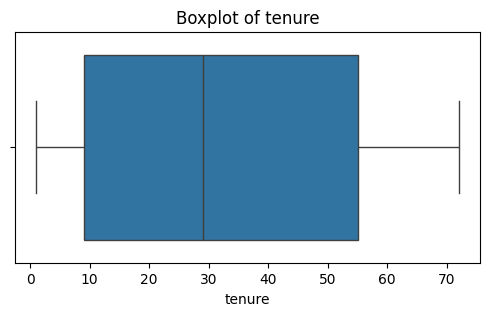

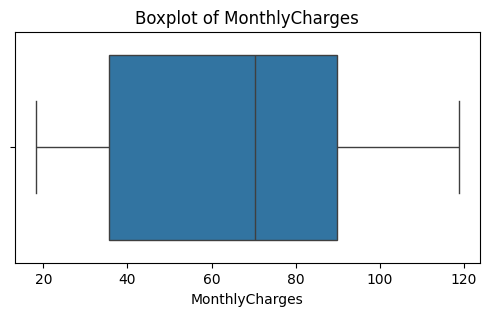

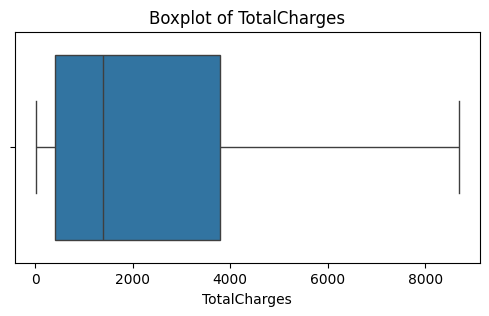

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


As we can see, from the box plots , there are no points outside the whiskers so there are no outliers to handle them

**E- Save the final dataset for future use**

In [21]:
df.to_csv(r"data\Cleaned_Telco_Customer_Churn.csv", index=False)

**STEP 3: Feature Engineering**

Import the cleaned data

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"data\Cleaned_Telco_Customer_Churn.csv")
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [24]:
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


**A- Create Tenure Category**

In [25]:
df['TenureCategory'] = pd.cut(
    df['tenure'],
    bins=[-1, 6, 24, 48, df['tenure'].max()],
    labels=['New', 'Short-term', 'Medium-term', 'Long-term']
)

**B- Engagement Score**

In [26]:
service_usage_cols = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
df['EngagementScore'] = df[service_usage_cols].sum(axis=1)

**C- Contract Risk**

In [27]:
df['ContractRisk'] = df['Contract'].map({
    'Month-to-month': 2,
    'One year': 1,
    'Two year': 0
})

**D- Financial Pressure**

In [28]:
df['FinancialPressure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

Re-order the columns and Save the final dataset

In [29]:
# Get all columns except the churn column
cols = [c for c in df.columns if c != 'Churn']
# Append 'Churn' at the end and reorder the data
cols.append('Churn')
df = df[cols]

# Save the final data
df.to_csv(r"data\Final_Cleaned_Telco_Customer_Churn.csv", index=False)


**STEP 4: Exploratory Data Analysis (EDA)**

In [30]:
import pandas as pd 
import numpy as np

df = pd.read_csv(r"data\Final_cleaned_Telco_Customer_Churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureCategory,EngagementScore,ContractRisk,FinancialPressure,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,...,Month-to-month,1,Electronic check,29.85,29.85,New,1,2,14.925000,0
1,Male,0,0,0,34,1,0,DSL,1,0,...,One year,0,Mailed check,56.95,1889.50,Medium-term,3,1,1.627143,0
2,Male,0,0,0,2,1,0,DSL,1,1,...,Month-to-month,1,Mailed check,53.85,108.15,New,3,2,17.950000,1
3,Male,0,0,0,45,0,0,DSL,1,0,...,One year,0,Bank transfer (automatic),42.30,1840.75,Medium-term,3,1,0.919565,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,...,Month-to-month,1,Electronic check,70.70,151.65,New,1,2,23.566667,1


**Distribution of the Churn ( target variable)**

<Axes: xlabel='Churn', ylabel='count'>

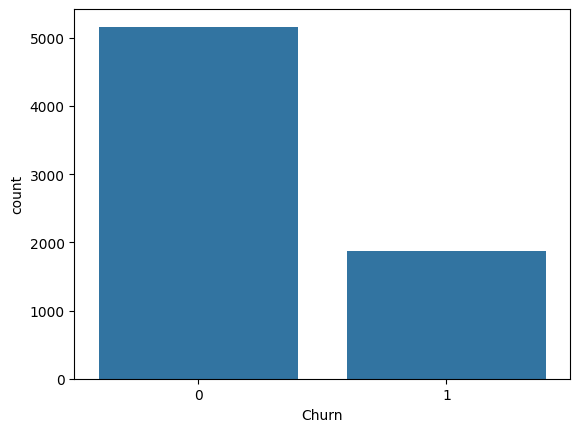

In [31]:
sns.countplot(x='Churn', data=df)


We can conclude that there is a class imbalance in the target variable

**Barplots to display relation between the churn rate and the categorical features**

Overall Churn rate 

In [32]:
churn_rate = df['Churn'].mean()
print(f"Overall Churn Rate: {churn_rate:.2%}")


Overall Churn Rate: 26.58%


Calculate the Churn rate by : Contract type, gender, Payment method, Internet service, and Tenure Category

In [33]:
def churn_rate_by(column):
    return (
        df.groupby(column)['Churn']
          .mean()
          .sort_values(ascending=False)
          .round(3)
    )


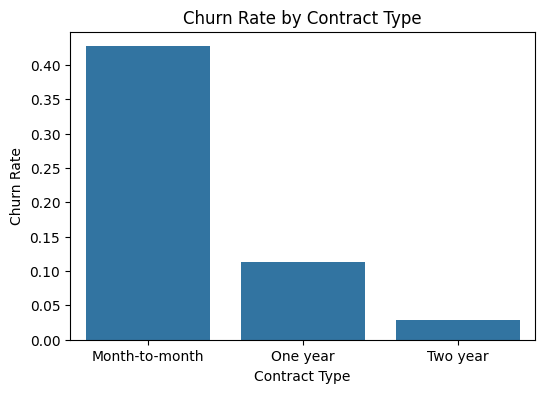

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    x=churn_rate_by('Contract').index,
    y=churn_rate_by('Contract').values
)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.show()


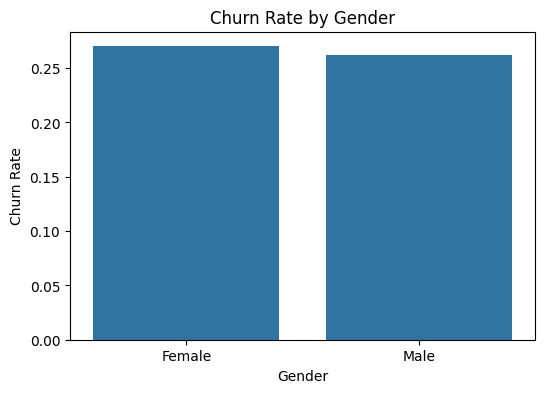

In [34]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=churn_rate_by('gender').index,
    y=churn_rate_by('gender').values
)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.xlabel('Gender')
plt.show()


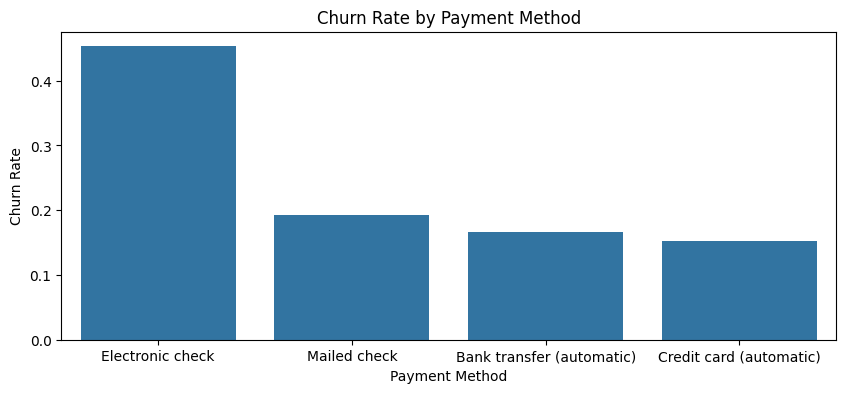

In [35]:
plt.figure(figsize=(10,4))
sns.barplot(
    x=churn_rate_by('PaymentMethod').index,
    y=churn_rate_by('PaymentMethod').values
)
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xlabel('Payment Method')
plt.show()

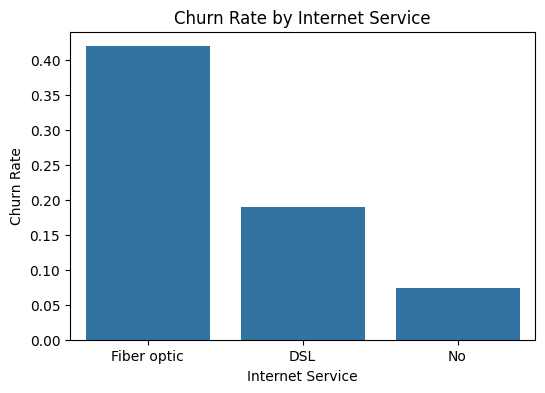

In [36]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=churn_rate_by('InternetService').index,
    y=churn_rate_by('InternetService').values
)
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.xlabel('Internet Service')
plt.show()

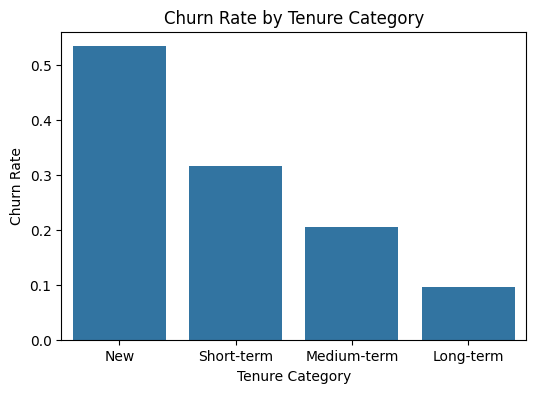

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=churn_rate_by('TenureCategory').index,
    y=churn_rate_by('TenureCategory').values
)
plt.title('Churn Rate by Tenure Category')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure Category')
plt.show()

* Gender has no significant impact on churn, as churn rates are nearly identical across genders.

* Customers on month-to-month contracts exhibit the highest churn rate, indicating lower commitment compared to long-term contracts.

* New customers with short tenure are more likely to churn, highlighting the importance of early customer engagement and onboarding.

* Customers using Fiber optic internet service show a higher churn rate, potentially due to higher costs or service quality expectations.

* Electronic check payment method is associated with higher churn, suggesting possible friction in the payment experience or correlation with higher-risk customer segments.

**Distribution of Monthly Charges**

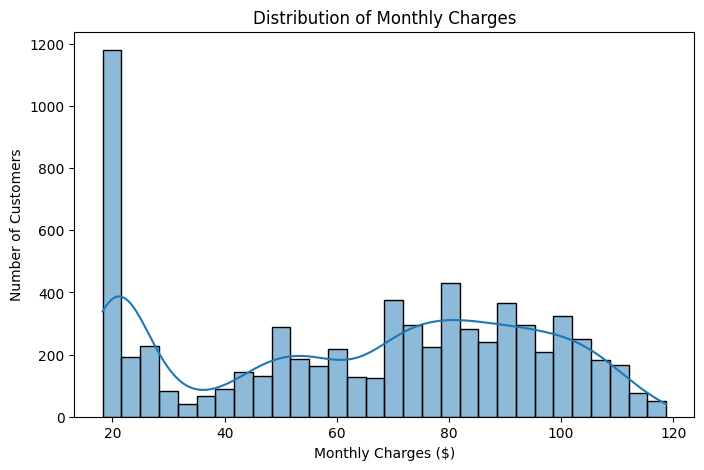

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.show()


The histogram of monthly charges shows that as monthly charges increase, the number of customers decreases. This indicates that most customers are concentrated in the lower to mid-range pricing tiers.

**Distribution of Total Charges by Churn**

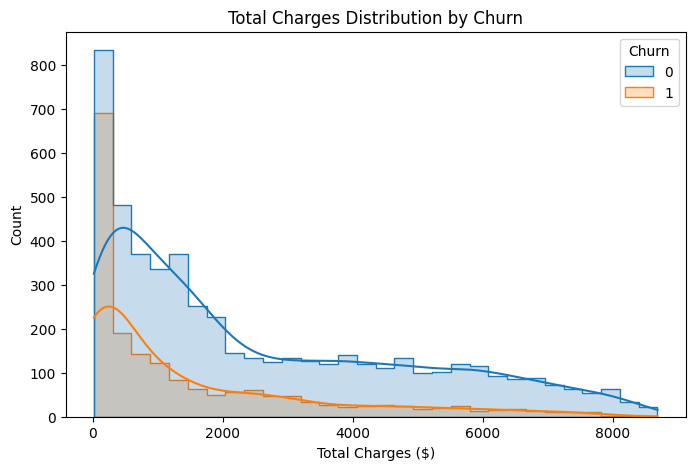

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=30, kde=True, element='step')
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Total Charges ($)')
plt.show()


The histogram of total charges by churn status shows that customers with higher total charges are less likely to churn. This suggests that long-term, high-value customers have stronger retention and are less prone to leaving the service.

**The correlation Heatmap**

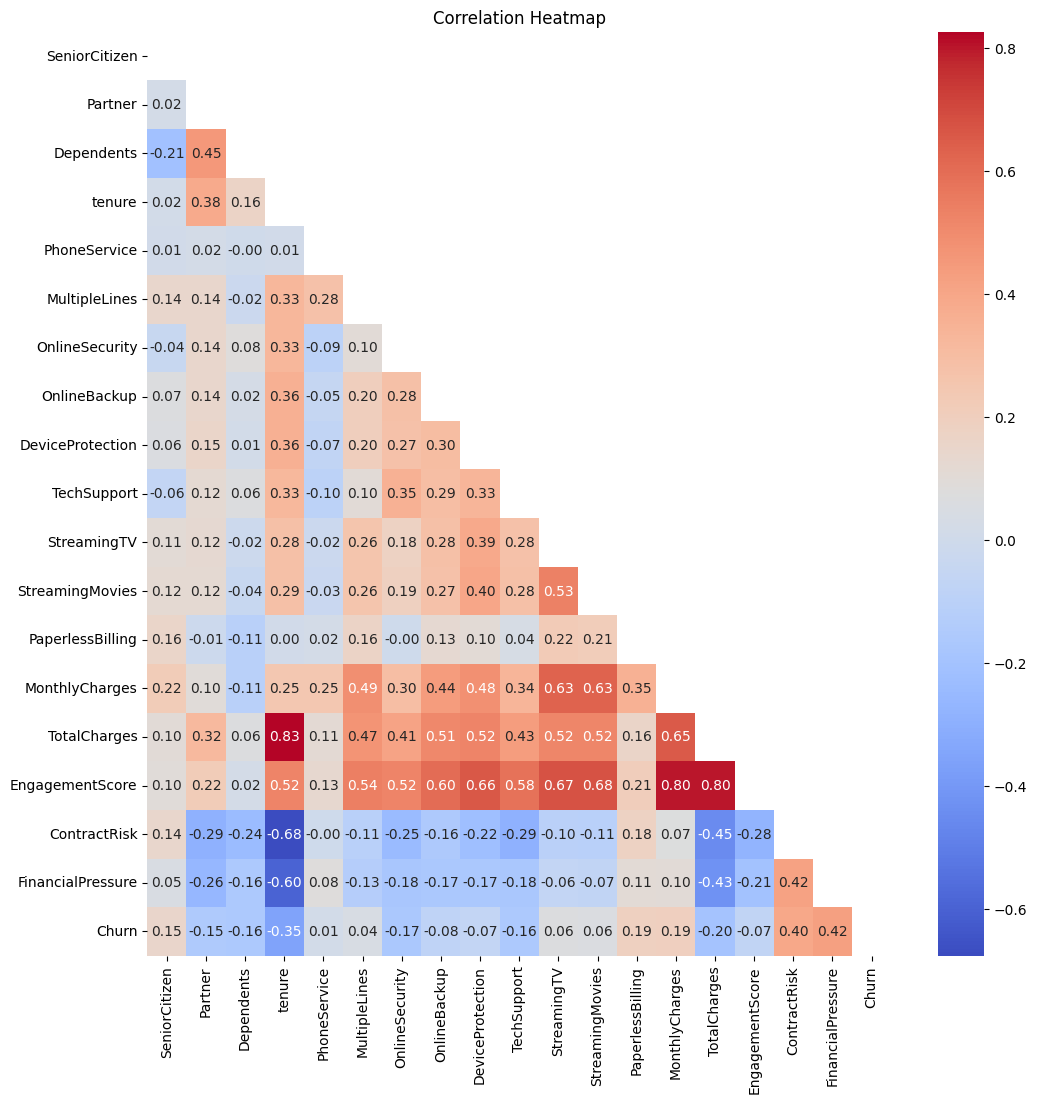

In [39]:

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,12))
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', mask=np.triu(corr))
plt.title('Correlation Heatmap')
plt.show()


The correlation heatmap highlights key factors associated with churn. Short-tenure customers, high contract risk, and financial pressure are positively correlated with churn, while higher total charges and longer tenure are negatively correlated, suggesting that long-term, high-value customers are less likely to leave. Strong correlations among services and between tenure and total charges indicate patterns in customer behavior and engagement that could inform retention strategies.

In [40]:
print(df.dtypes)

gender                object
SeniorCitizen          int64
Partner                int64
Dependents             int64
tenure                 int64
PhoneService           int64
MultipleLines          int64
InternetService       object
OnlineSecurity         int64
OnlineBackup           int64
DeviceProtection       int64
TechSupport            int64
StreamingTV            int64
StreamingMovies        int64
Contract              object
PaperlessBilling       int64
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
TenureCategory        object
EngagementScore        int64
ContractRisk           int64
FinancialPressure    float64
Churn                  int64
dtype: object


**STEP 5: SQL Analysis**